<a href="https://colab.research.google.com/github/Challenge-Submission-Group-D/Group-D/blob/main/Final_AQB371_Software_SEASONAL_VACCINE_PREDICTION_FULL_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HACKATHON: SEASONAL VACCINE PREDICTION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Sklearn preprocessing & utilities
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [3]:
# Sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [4]:
# Sklearn metrics
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

In [5]:
# Load Data
train_df = pd.read_csv("/content/dataset_A_training.csv")
test_df = pd.read_csv("/content/dataset_A_training.csv")

In [6]:
train_df.shape

(4756, 31)

In [7]:
test_df.shape

(4756, 31)

In [8]:
train_df.head()

,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [9]:
# Basic info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

# Handling missing values

In [10]:
train_df.isnull().sum()

,0
respondent_id,0
flu_concern,12
flu_knowledge,23
behavioral_antiviral_meds,14
behavioral_avoidance,32
behavioral_face_mask,3
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,9
behavioral_touch_face,19


In [11]:
test_df.isnull().sum()

,0
respondent_id,0
flu_concern,12
flu_knowledge,23
behavioral_antiviral_meds,14
behavioral_avoidance,32
behavioral_face_mask,3
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,9
behavioral_touch_face,19


In [12]:
# Separate numerical and categorical columns
TARGET = 'seasonal_vaccine'
ID_COL = 'respondent_id'

numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target and ID
for col in [TARGET, ID_COL]:
    if col in numerical_cols:
        numerical_cols.remove(col)
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

In [13]:
# Median Imputation for Numerical Features
for col in numerical_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    test_df[col].fillna(test_df[col].median(), inplace=True)

In [14]:
# Mode Imputation for Categorical Features
for col in categorical_cols:
    mode_value = train_df[col].mode()[0]
    train_df[col].fillna(mode_value, inplace=True)
    test_df[col].fillna(mode_value, inplace=True)

 # Exploratory Data Analysis (EDA)

In [15]:
train_df.describe()

,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,seasonal_vaccine
count,4756.00000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,...,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000
mean,2378.50000,1.644029,1.291632,0.052145,0.735913,0.073802,0.836838,0.364802,0.335997,0.689655,...,0.290160,0.088520,0.132675,0.933978,4.093146,2.858074,2.124685,0.896552,0.536585,0.536375
std,1373.08327,0.918823,0.617738,0.222342,0.440892,0.261475,0.369553,0.481425,0.472387,0.462683,...,0.453884,0.284079,0.339258,0.248346,1.065444,1.400406,1.323655,0.756202,0.934065,0.498728
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,2.000000,1.000000,0.000000,1.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,3.250000,1.000000,1.000000,1.000000
max,4756.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


In [16]:
# Target variable distribution
target_counts = train_df['seasonal_vaccine'].value_counts()
print(f"Target class distribution:\n{target_counts}")

Target class distribution:
seasonal_vaccine
1    2551
0    2205
Name: count, dtype: int64


In [17]:
print(f"Class balance (% vaccinated): {target_counts[1]/len(train_df)*100:.1f}%")

Class balance (% vaccinated): 53.6%


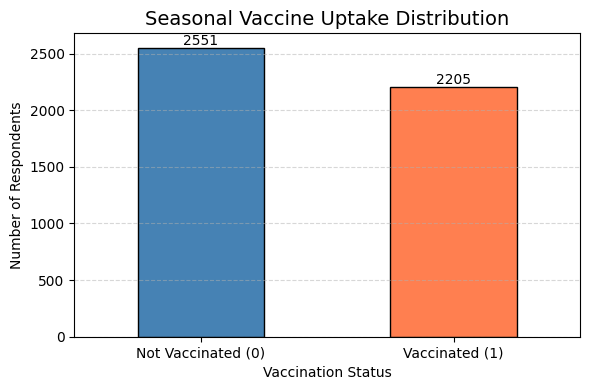

In [18]:
plt.figure(figsize=(6,4))

ax = target_counts.plot(
    kind='bar',
    color=['steelblue','coral'],
    edgecolor='black'
)

plt.title('Seasonal Vaccine Uptake Distribution', fontsize=14)
plt.xlabel('Vaccination Status')
plt.ylabel('Number of Respondents')

ax.set_xticklabels(['Not Vaccinated (0)','Vaccinated (1)'], rotation=0)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

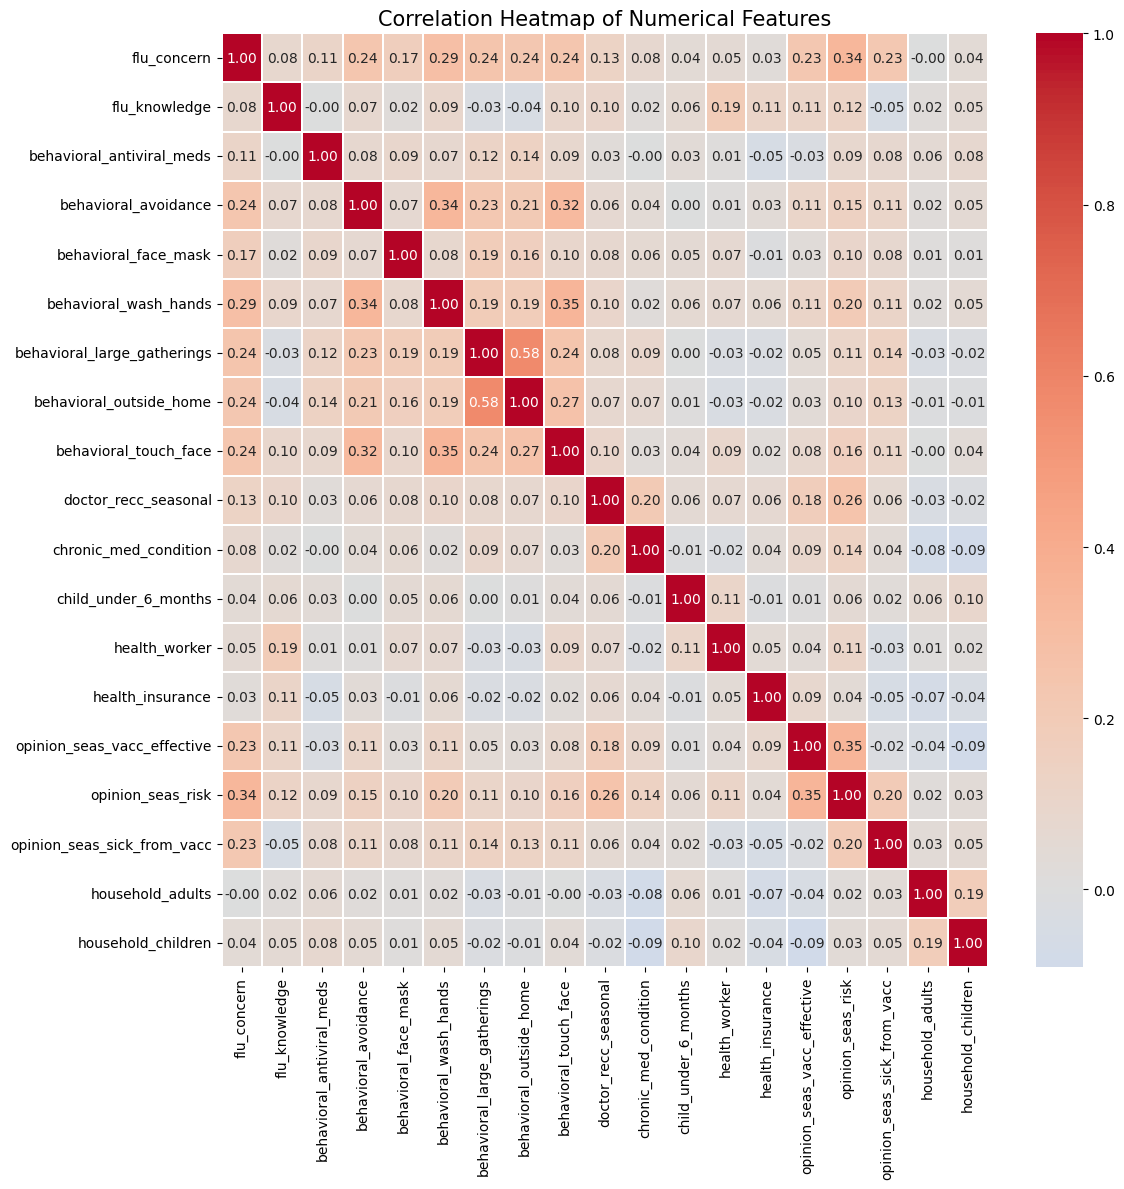

In [19]:
# Correlation Heatmap
corr_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(12,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    square=False
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=15
)

plt.tight_layout()
plt.show()

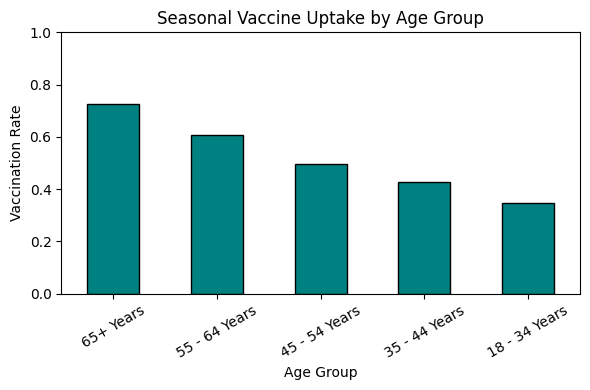

In [20]:
# Vaccine Uptake by Age Group
uptake = train_df.groupby(
    'age_group'
)['seasonal_vaccine'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(6,4))

uptake.plot(
    kind='bar',
    color='teal',
    edgecolor='black'
)

plt.title('Seasonal Vaccine Uptake by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Vaccination Rate')

plt.ylim(0,1)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

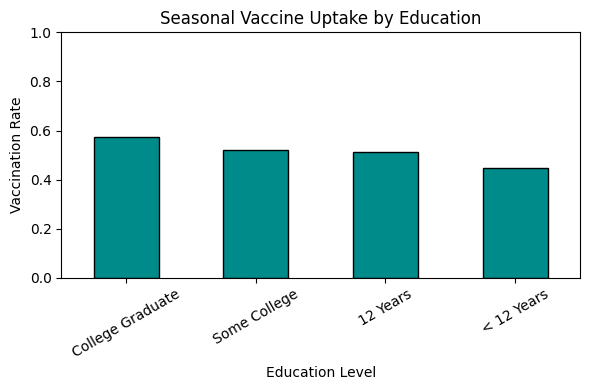

In [21]:
# Vaccine Uptake by Education
uptake = train_df.groupby(
    'education'
)['seasonal_vaccine'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(6,4))

uptake.plot(
    kind='bar',
    color='darkcyan',
    edgecolor='black'
)

plt.title('Seasonal Vaccine Uptake by Education')
plt.xlabel('Education Level')
plt.ylabel('Vaccination Rate')

plt.ylim(0,1)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

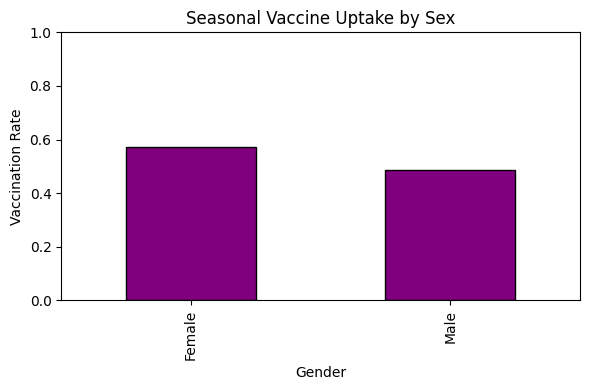

In [22]:
# Vaccine Uptake by Gender
uptake = train_df.groupby(
    'sex'
)['seasonal_vaccine'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(6,4))

uptake.plot(
    kind='bar',
    color='purple',
    edgecolor='black'
)

plt.title('Seasonal Vaccine Uptake by Sex')
plt.xlabel('Gender')
plt.ylabel('Vaccination Rate')

plt.ylim(0,1)

plt.tight_layout()
plt.show()

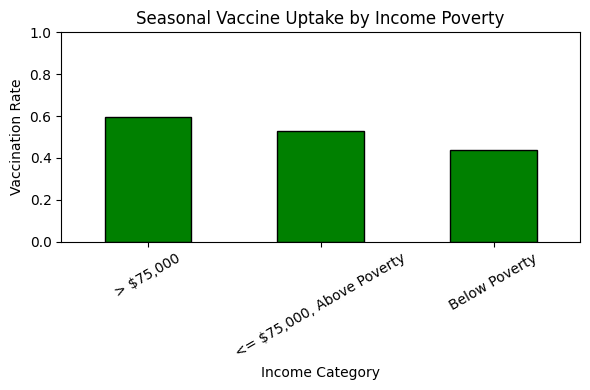

In [23]:
# Vaccine Uptake by Income Poverty
uptake = train_df.groupby(
    'income_poverty'
)['seasonal_vaccine'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(6,4))

uptake.plot(
    kind='bar',
    color='green',
    edgecolor='black'
)

plt.title('Seasonal Vaccine Uptake by Income Poverty')
plt.xlabel('Income Category')
plt.ylabel('Vaccination Rate')

plt.ylim(0,1)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Data Preprocessing & Feature Engineering

In [24]:
# Separate features and target
X_train = train_df.drop(columns=[TARGET, ID_COL])

In [25]:
y_train      = train_df[TARGET]

In [26]:
X_test  = test_df.drop(columns=[ID_COL])

In [27]:
test_ids     = test_df[ID_COL]

In [28]:
# Identify column types
numeric_features  = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_test.select_dtypes(include='object').columns.tolist()

In [29]:
# Encode categorical features with LabelEncoder
le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit on combined train+test to avoid unseen labels
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_dict[col] = le

In [30]:
# Feature Engineering: Create interaction/aggregate features
# Risk awareness score: sum of flu concern + flu knowledge
X_train['risk_awareness'] = X_train['flu_concern'] + X_train['flu_knowledge']
X_test['risk_awareness']  = X_test['flu_concern']  + X_test['flu_knowledge']

In [31]:
# Protective behaviour score: sum of all behavioral_ columns
behav_cols = [c for c in numeric_features if c.startswith('behavioral_')]
X_train['behaviour_score'] = X_train[behav_cols].sum(axis=1)
X_test['behaviour_score']  = X_test[behav_cols].sum(axis=1)

In [32]:
# Pro-vaccine opinion score: effective belief minus sick fear + risk
X_train['vacc_opinion_score'] = (
    X_train['opinion_seas_vacc_effective'] +
    X_train['opinion_seas_risk'] -
    X_train['opinion_seas_sick_from_vacc']
)
X_test['vacc_opinion_score'] = (
    X_test['opinion_seas_vacc_effective'] +
    X_test['opinion_seas_risk'] -
    X_test['opinion_seas_sick_from_vacc']
)

In [35]:
NAME = 'seasonal_vaccine'
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test.drop(columns=[NAME]))

# Model 1: Baseline Model – Logistic Regression

In [36]:
# Baseline Model – Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)

In [37]:
# Cross-validation (5-fold, ROC-AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train,
                                cv=cv, scoring='roc_auc')

In [38]:
print(f"CV ROC-AUC scores : {lr_cv_scores.round(4)}")

CV ROC-AUC scores : [0.8445 0.842  0.8413 0.8474 0.8397]


In [39]:
print(f"Mean CV ROC-AUC   : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

Mean CV ROC-AUC   : 0.8430 ± 0.0027


In [40]:
# Fit and predict
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
lr_train_pred  = lr_model.predict(X_train_scaled)

In [42]:
lr_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]

In [43]:
lr_test_proba  = lr_model.predict_proba(X_test_scaled)[:, 1]

In [44]:
print(f"\nTrain Accuracy : {accuracy_score(y_train, lr_train_pred):.4f}")


Train Accuracy : 0.7761


In [46]:
print(f"Train ROC-AUC  : {roc_auc_score(y_train, lr_train_proba):.4f}")

Train ROC-AUC  : 0.8487


In [47]:
print(classification_report(y_train, lr_train_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      2205
           1       0.79      0.79      0.79      2551

    accuracy                           0.78      4756
   macro avg       0.77      0.77      0.77      4756
weighted avg       0.78      0.78      0.78      4756



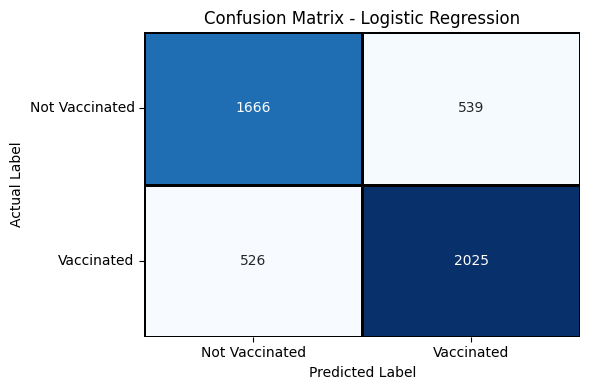

In [48]:
# Logistic Regression Confusion Matrix
cm = confusion_matrix(y_train, lr_train_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='black'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated']
)

plt.yticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated'],
    rotation=0
)

plt.tight_layout()
plt.show()

In [49]:
submission_1 = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': (lr_test_proba >= 0.5).astype(int)
})

In [51]:
submission_1.head()

,respondent_id,seasonal_vaccine
0,1,0
1,2,0
2,3,1
3,4,1
4,5,0


In [52]:
submission_1.to_csv('submission_1_logistic_regression.csv', index=False)

# Model 2 – Decision Tree Classifier

In [53]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [54]:
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='roc_auc')

In [55]:
print(f"CV ROC-AUC scores : {dt_cv_scores.round(4)}")

CV ROC-AUC scores : [0.804  0.7835 0.8093 0.798  0.807 ]


In [56]:
print(f"Mean CV ROC-AUC   : {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}")

Mean CV ROC-AUC   : 0.8004 ± 0.0093


In [57]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [58]:
dt_train_pred  = dt_model.predict(X_train)

In [59]:
dt_train_proba = dt_model.predict_proba(X_train)[:, 1]

In [62]:
dt_test_proba  = dt_model.predict_proba(X_test.drop(columns=[NAME]))[:, 1]

In [63]:
print(f"\nTrain Accuracy : {accuracy_score(y_train, dt_train_pred):.4f}")


Train Accuracy : 0.8057


In [64]:
print(f"Train ROC-AUC  : {roc_auc_score(y_train, dt_train_proba):.4f}")

Train ROC-AUC  : 0.8842


In [65]:
print(classification_report(y_train, dt_train_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79      2205
           1       0.83      0.80      0.82      2551

    accuracy                           0.81      4756
   macro avg       0.80      0.81      0.81      4756
weighted avg       0.81      0.81      0.81      4756



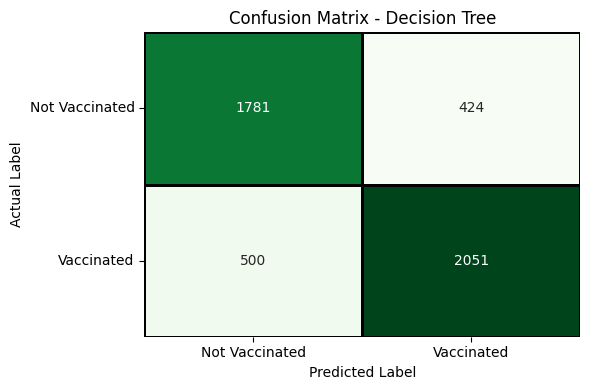

In [66]:
# Decision Tree Confusion Matrix
cm = confusion_matrix(y_train, dt_train_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    linewidths=1,
    linecolor='black'
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated']
)

plt.yticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated'],
    rotation=0
)

plt.tight_layout()
plt.show()

In [67]:
submission_2 = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': (dt_test_proba >= 0.5).astype(int)
})

In [68]:
submission_2.head()

,respondent_id,seasonal_vaccine
0,1,0
1,2,0
2,3,1
3,4,1
4,5,0


In [69]:
submission_2.to_csv('submission_2_decision_tree.csv', index=False)

# Model 3 – Random Forest Classifier

In [70]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

In [71]:
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

In [72]:
print(f"CV ROC-AUC scores : {rf_cv_scores.round(4)}")

CV ROC-AUC scores : [0.851  0.8365 0.8494 0.8486 0.8475]


In [73]:
print(f"Mean CV ROC-AUC   : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

Mean CV ROC-AUC   : 0.8466 ± 0.0052


In [74]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [75]:
rf_train_pred  = rf_model.predict(X_train)

In [76]:
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]

In [78]:
rf_test_proba  = rf_model.predict_proba(X_test.drop(columns=[NAME]))[:, 1]

In [79]:
print(f"\nTrain Accuracy : {accuracy_score(y_train, rf_train_pred):.4f}")


Train Accuracy : 0.8518


In [80]:
print(f"Train ROC-AUC  : {roc_auc_score(y_train, rf_train_proba):.4f}")

Train ROC-AUC  : 0.9334


In [81]:
print(classification_report(y_train, rf_train_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      2205
           1       0.85      0.87      0.86      2551

    accuracy                           0.85      4756
   macro avg       0.85      0.85      0.85      4756
weighted avg       0.85      0.85      0.85      4756



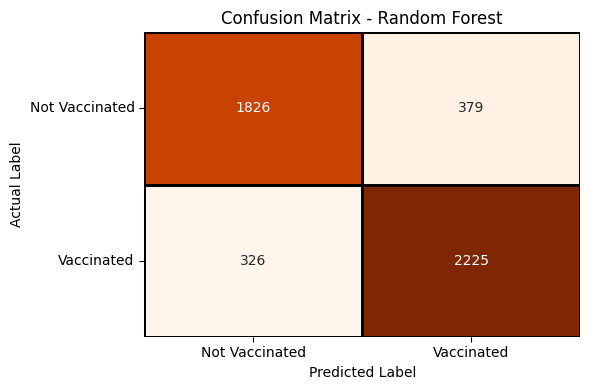

In [82]:
# Random Forest Confusion Matrix
cm = confusion_matrix(y_train, rf_train_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    cbar=False,
    linewidths=1,
    linecolor='black'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated']
)

plt.yticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated'],
    rotation=0
)

plt.tight_layout()
plt.show()

In [83]:
submission_3 = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': (rf_test_proba >= 0.5).astype(int)
})

In [84]:
submission_3.to_csv('submission_3_random_forest.csv', index=False)

# Model 4 – Gradient Boosting Classifier

In [85]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

In [86]:
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring='roc_auc')

In [87]:
print(f"CV ROC-AUC scores : {gb_cv_scores.round(4)}")

CV ROC-AUC scores : [0.8529 0.8363 0.8509 0.8477 0.847 ]


In [88]:
print(f"Mean CV ROC-AUC   : {gb_cv_scores.mean():.4f} ± {gb_cv_scores.std():.4f}")

Mean CV ROC-AUC   : 0.8470 ± 0.0058


In [89]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=5, max_features='sqrt',
                           min_samples_leaf=10, min_samples_split=20,
                           n_estimators=300, random_state=42, subsample=0.8)

In [90]:
gb_train_pred  = gb_model.predict(X_train)

In [91]:
gb_train_proba = gb_model.predict_proba(X_train)[:, 1]

In [93]:
gb_test_proba  = gb_model.predict_proba(X_test.drop(columns=[NAME]))[:, 1]

In [94]:
print(f"\nTrain Accuracy : {accuracy_score(y_train, gb_train_pred):.4f}")


Train Accuracy : 0.8633


In [95]:
print(f"Train ROC-AUC  : {roc_auc_score(y_train, gb_train_proba):.4f}")

Train ROC-AUC  : 0.9372


In [96]:
print(classification_report(y_train, gb_train_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      2205
           1       0.86      0.89      0.87      2551

    accuracy                           0.86      4756
   macro avg       0.86      0.86      0.86      4756
weighted avg       0.86      0.86      0.86      4756



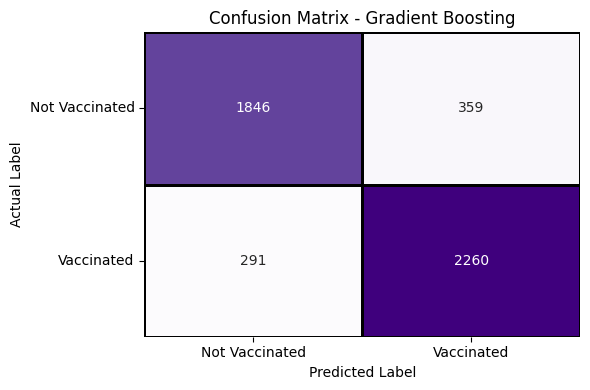

In [97]:
# Gradient Boosting Confusion Matrix
cm = confusion_matrix(y_train, gb_train_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    cbar=False,
    linewidths=1,
    linecolor='black'
)

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated']
)

plt.yticks(
    [0.5, 1.5],
    ['Not Vaccinated', 'Vaccinated'],
    rotation=0
)

plt.tight_layout()
plt.show()

In [98]:
submission_4 = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': (gb_test_proba >= 0.5).astype(int)
})

In [99]:
submission_4.to_csv('submission_4_gradient_boosting.csv', index=False)

# Model 5 – XGBoost Classifier

In [101]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
n_estimators=500,
learning_rate=0.03,
max_depth=5,
min_child_weight=3,
subsample=0.8,
colsample_bytree=0.8,
objective='binary:logistic',
eval_metric='auc',
random_state=42,
n_jobs=-1
)

In [102]:
# Cross Validation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

In [103]:
print(xgb_cv_scores)

[0.85256777 0.83585879 0.84616958 0.84748566 0.84663199]


In [104]:
print(f"\nMean CV ROC-AUC : {xgb_cv_scores.mean():.4f}")


Mean CV ROC-AUC : 0.8457


In [105]:
print(f"Std CV ROC-AUC  : {xgb_cv_scores.std():.4f}")

Std CV ROC-AUC  : 0.0054


In [106]:
# Train Model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [107]:
# Predictions
xgb_train_pred = xgb_model.predict(X_train)

In [108]:
xgb_train_proba = xgb_model.predict_proba(X_train)[:,1]

In [110]:
xgb_test_proba  = xgb_model.predict_proba(X_test.drop(columns=[NAME]))[:, 1]

In [111]:
# Evaluation

print(f"\nTrain Accuracy : {accuracy_score(y_train,xgb_train_pred):.4f}")


Train Accuracy : 0.8694


In [112]:
print(f"Train ROC-AUC : {roc_auc_score(y_train,xgb_train_proba):.4f}")

Train ROC-AUC : 0.9438


In [113]:
print(classification_report(
    y_train,
    xgb_train_pred
))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2205
           1       0.87      0.89      0.88      2551

    accuracy                           0.87      4756
   macro avg       0.87      0.87      0.87      4756
weighted avg       0.87      0.87      0.87      4756



In [114]:
submission_xgb = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': (xgb_test_proba >= 0.5).astype(int)

})

In [115]:
submission_xgb.to_csv(
    'submission_5_xgboost.csv',
    index=False
)